## CELL 1 — Import the Libraries

In [1]:
# Libraries are pre-built tools that save us from writing everything ourselves

import pandas as pd          # for loading and working with data (like Excel in Python)
import numpy as np           # for math/number operations
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns        # nicer-looking charts built on top of matplotlib
import warnings
warnings.filterwarnings('ignore')  # hide minor warnings so output looks cleaner

print("Libraries loaded!")

Libraries loaded!


## CELL 2 — Load the Dataset

In [ ]:
# pd.read_csv() reads a CSV file and stores it as a DataFrame (like a table)
# df = pd.read_csv(r'<csv file location')
df = pd.read_csv(r'c:\Users\teybo\OneDrive\Documents\BMDS3003-Data-Science-Telcom-Customer-Churn-\Telco_Cusomer_Churn.csv')

# .shape tells you (rows, columns)
print("Shape:", df.shape)

# .head() shows the first 5 rows
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## CELL 3 — Understand Data

In [4]:
# .info() shows column names, data types, and non-null counts
df.info()

# .describe() gives statistics for number columns (mean, min, max, etc.)
df.describe()

# Check for missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Cell 4 - Explore the Target Column (Churn)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


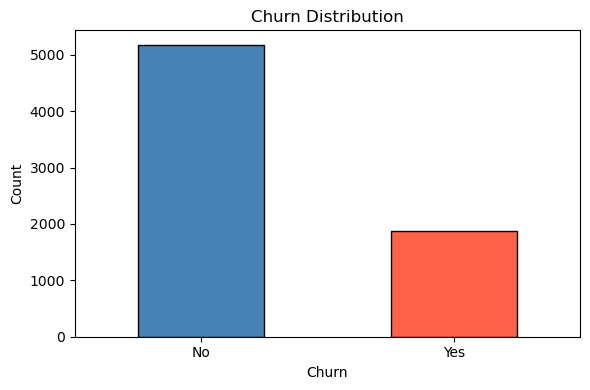

In [6]:
# Count how many Yes/No in the Churn column
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)  # as percentages

# Visualise it
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Cell 5 - Explore Key Features (EDA)

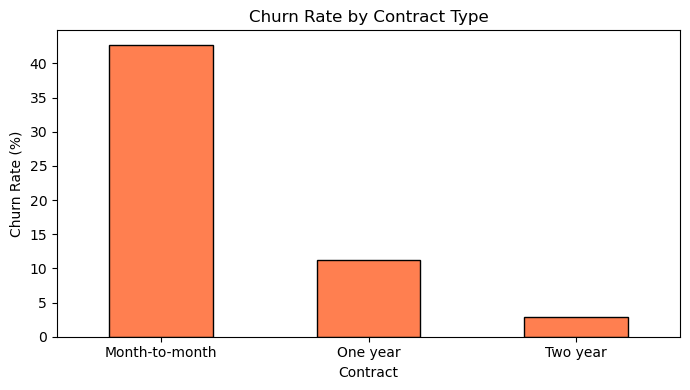

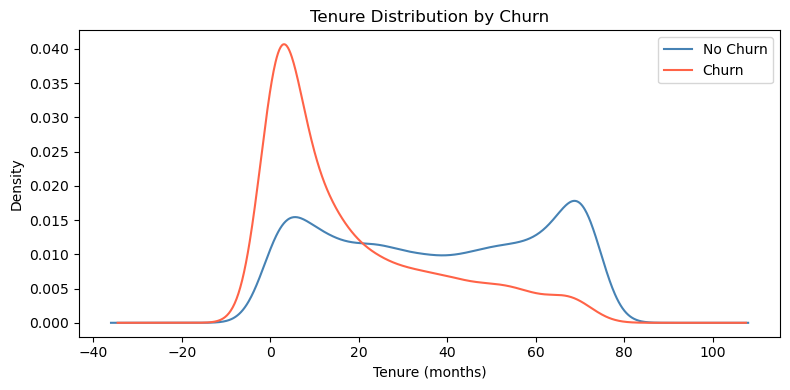

In [7]:
# Churn rate by Contract type — one of the most important features
plt.figure(figsize=(7, 4))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
contract_churn.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Distribution of tenure (how long customers stay) vs Churn
plt.figure(figsize=(8, 4))
df[df['Churn'] == 'No']['tenure'].plot(kind='kde', label='No Churn', color='steelblue')
df[df['Churn'] == 'Yes']['tenure'].plot(kind='kde', label='Churn', color='tomato')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.legend()
plt.tight_layout()
plt.show()

## Cell 6 - Fix the TotalCharges

In [8]:
# TotalCharges is stored as text (object), convert it to number
# Any blank/empty string becomes NaN automatically
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many NaN appeared
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

# These 11 rows are new customers (tenure = 0, never been billed)
# So we fill with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("After fix:", df["TotalCharges"].isnull().sum(), "missing values")
print("✅ TotalCharges fixed!")

Missing TotalCharges: 11
After fix: 0 missing values
✅ TotalCharges fixed!


## Cell 7 - Drop customerID

In [9]:
# customerID is just a unique ID number, it doesn't help predict churn
# (worse — for a linear model it would even be misread as a giant numeric feature)
df = df.drop(columns=["customerID"])

print("New shape:", df.shape)
print("✅ customerID removed!")

New shape: (7043, 20)
✅ customerID removed!


## Cell 8 - Encode Churn

In [10]:
# Machine learning models only understand numbers, not text
# So we convert: Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())
print("✅ Churn encoded!")

Churn
0    5174
1    1869
Name: count, dtype: int64
✅ Churn encoded!


## Cell 9 - Encode Text Columns

In [11]:
# Binary columns (only 2 possible values) -> simple 1/0 mapping
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0})
df["Dependents"] = df["Dependents"].map({"Yes": 1, "No": 0})
df["PhoneService"] = df["PhoneService"].map({"Yes": 1, "No": 0})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})

print("✅ Binary columns encoded!")

# Multi-value columns -> One-Hot Encoding
# This creates a new 0/1 column for each possible value. For Logistic Regression
# specifically this matters even more than for KNN: the model reads a raw integer
# category (e.g. DSL=0, Fiber=1, None=2) as an ORDERED, evenly-spaced quantity,
# which would attach a meaningless, misleading coefficient to it. One-hot avoids that.
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after one-hot encoding:", df.shape)
print("✅ Text columns encoded!")

✅ Binary columns encoded!
Shape after one-hot encoding: (7043, 31)
✅ Text columns encoded!


## Cell 10 - Train / Test Split First, Then Scale

Why order matters: if we scale (fit StandardScaler) on the whole dataset and then split into train/test, the scaler has already "seen" the test rows when it computed its mean/std. That's data leakage - the test set is supposed to be completely untouched until evaluation. 

So we split first, fit the scaler on X_train only, then use that same fitted scaler to transform X_test. This matches shared/preporcessing.py, which the other members' scripts rely on.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X = all columns except Churn (the inputs), y = Churn (what we predict)
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Split BEFORE scaling — stratify=y keeps the same 73/27 churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the scaler on TRAIN ONLY, then apply it to both — no leakage
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"Features:      {X_train.shape[1]} columns")
print("✅ Split done, scaler fit on train only!")


Training set:  5634 rows
Test set:      1409 rows
Features:      30 columns
✅ Split done, scaler fit on train only!


## Cell 11 - What does Random Forest Do?

Unlike a Decision Tree, which makes predictions using a single tree, Random Forest builds multiple decision trees and combines their predictions to produce a more accurate result. 

It works in four main steps: 
1. Randomly selects training samples, where each tree is trained on a different subset of the original dataset. 
2. Randomly selects a subset of features whenever a tree decides where to split. This makes every tree slightly different and prevents all tree from learning the same patterns. 
3. Each decision tree will makes its own prediction independetly. Some trees may predict Churn and some may predict No Churn. 
4. Random Forest combines all predictions using Majority Voting. The class that receives the highest number of votes becomes the final prediction. 

Unlike Logistic Regression, Random Forest does not calculate probabilities using a mathematical equation. Instead it relies on the collective decision of many Decision Tree, making it more robust and less likely to overfit than a single Decision Tree. 

Below is a simple demo showing how several Decision Tree vote to determine the final prediction for one customer. 

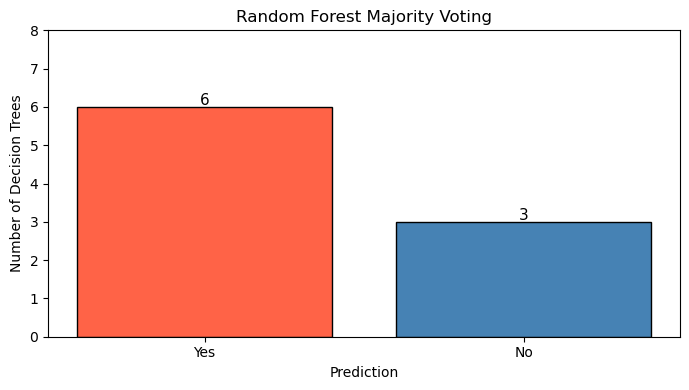

Predictions from each tree:
Tree 1: Yes
Tree 2: Yes
Tree 3: No
Tree 4: Yes
Tree 5: Yes
Tree 6: No
Tree 7: Yes
Tree 8: No
Tree 9: Yes

Votes
Counter({'Yes': 6, 'No': 3})

Final Prediction = Yes


In [13]:
import matplotlib.pyplot as plt
from collections import Counter

# Example predictions from 9 decision trees
tree_predictions = [
    "Yes",
    "Yes",
    "No",
    "Yes",
    "Yes",
    "No",
    "Yes",
    "No",
    "Yes"
]

# Count the votes
vote_counts = Counter(tree_predictions)

# Plot
plt.figure(figsize=(7,4))

bars = plt.bar(
    vote_counts.keys(),
    vote_counts.values(),
    color=["tomato", "steelblue"],
    edgecolor="black"
)

# Display vote count above bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.05,
        int(bar.get_height()),
        ha='center',
        fontsize=11
    )

plt.title("Random Forest Majority Voting")
plt.xlabel("Prediction")
plt.ylabel("Number of Decision Trees")
plt.ylim(0, max(vote_counts.values())+2)

plt.tight_layout()
plt.show()

print("Predictions from each tree:")
for i, prediction in enumerate(tree_predictions, start=1):
    print(f"Tree {i}: {prediction}")

print("\nVotes")
print(vote_counts)

print(f"\nFinal Prediction = {vote_counts.most_common(1)[0][0]}")

## Cell 12 - Building the Random Forest Model

A Random Forest classifier is created by specifying several parameters that control how the forest is built. In this implementation, the following parameters are used:

- n_estimators = 100: Builds 100 Decision Trees. A larger number of trees generally improves prediction stability, although it also increases training time.
- random_state = 42: Ensures that the same random samples and feature selections are generated each time the notebook is executed, making the results reproducible.
- criterion = "gini": Uses the Gini Impurity measure to determine the best feature splits when constructing each Decision Tree. Lower impurity indicates better separation between classes.

Once the Random Forest model has been created, it is trained using the training dataset (X_train and y_train). During training, the algorithm automatically constructs multiple Decision Trees, each learning from different random samples and subsets of features.

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    criterion="gini"

)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

print("Number of trees built:", len(rf_model.estimators_))
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Random Forest model trained successfully!
Number of trees built: 100
Training samples: 5634
Testing samples : 1409
Number of features: 30


## Cell 13 - Making Predictions Using the Random Forest Model

After the Random Forest model has been successfully trained, it can now be used to predict whether customers in the testing dataset are likely to churn.

The predict() function applies the trained Random Forest model to each customer in the testing dataset (X_test). For every customer, each Decision Tree independently predicts whether the customer will churn or not. The Random Forest classifier then combines these predictions using Majority Voting, and the class receiving the highest number of votes becomes the final prediction.

The predicted labels are stored in the variable y_pred, while the actual labels remain in y_test. These values will be compared in the following sections to evaluate the performance of the model.

In [15]:
# Predict customer churn using the testing dataset
y_pred = rf_model.predict(X_test)

# Compare predictions with actual values
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,1
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,1,1


## Cell 14 - Evaluating the Random Forest Model

One of the most common evaluation metrics for classification problems is Accuracy. Accuracy measures the proportion of correctly classified instances out of the total number of predictions made.

The accuracy is calculated using the following formula:

Accuracy= Total Number of Predictions / Number of Correct Predictions

An accuracy of 100% means every prediction is correct, while an accuracy of 50% means the model performs no better than random guessing for a balanced binary classification problem.

Although accuracy provides a quick overview of model performance, it does not distinguish between different types of prediction errors. Therefore, additional evaluation metrics such as Precision, Recall, F1-score, and the Confusion Matrix will also be examined in the following sections.

In [18]:
from sklearn.metrics import accuracy_score

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 0.7842
Model Accuracy: 78.42%


## Cell 15 - Classification Report

While Accuracy provides an overall measure of model performance, it does not explain how well the model predicts each class individually.

For customer churn prediction, identifying customers who are likely to churn is often more important than simply achieving a high accuracy. Therefore, additional evaluation metrics are required.

The Classification Report provides four important metrics:
- Precision – Measures how many customers predicted as churn actually churned.
- Recall – Measures how many actual churn customers were successfully identified by the model.
- F1-score – The harmonic mean of Precision and Recall, providing a balanced measure of both.
- Support – The number of actual instances for each class in the testing dataset.

These metrics provide a more comprehensive evaluation of the Random Forest model than accuracy alone.

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate the classification report
report = classification_report(y_test, y_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()

report_df.round(3)

,precision,recall,f1-score,support
0,0.826,0.895,0.859,1035.000
1,0.622,0.479,0.541,374.000
accuracy,0.784,0.784,0.784,0.784
macro avg,0.724,0.687,0.700,1409.000
weighted avg,0.772,0.784,0.775,1409.000


## Cell 16 - Confusion Matrix

A Confusion Matrix is a table that summarizes the performance of a classification model by comparing the actual class labels with the predicted class labels.

Unlike Accuracy or the Classification Report, the Confusion Matrix shows exactly how many predictions are correct and incorrect, making it easier to understand the types of mistakes made by the model.

For a binary classification problem such as customer churn prediction, the Confusion Matrix consists of four outcomes:
- True Negative (TN): Customers who did not churn and were correctly predicted as not churning.
- False Positive (FP): Customers who did not churn but were incorrectly predicted as churning.
- False Negative (FN): Customers who actually churned but were incorrectly predicted as not churning.
- True Positive (TP): Customers who churned and were correctly predicted as churning.

An effective churn prediction model aims to maximize the number of True Positives while minimizing False Negatives, as failing to identify customers who are likely to churn may result in lost business opportunities.

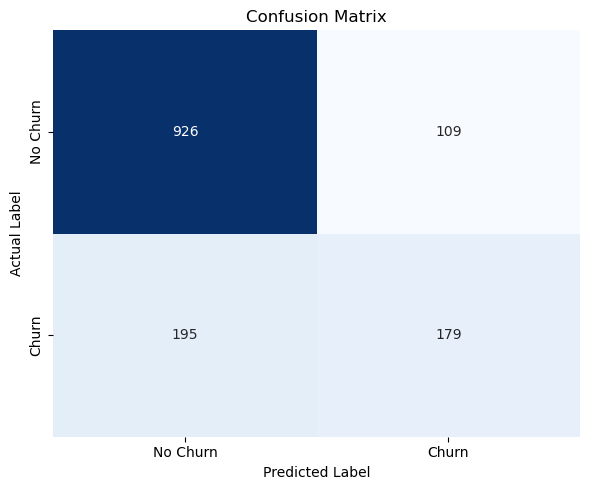

True Negatives (TN): 926
False Positives (FP): 109
False Negatives (FN): 195
True Positives (TP): 179


In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

## Cell 17 - Receiver Operating Characteristic (ROC) Curve ad AUC

While the Confusion Matrix and Classification Report evaluate the model at a single classification threshold (typically 0.5), the Receiver Operating Characteristic (ROC) Curve evaluates the model across all possible classification thresholds.

The ROC Curve illustrates the trade-off between:
- True Positive Rate (TPR), also known as Recall or Sensitivity, which measures the proportion of actual churn customers correctly identified by the model.
- False Positive Rate (FPR), which measures the proportion of non-churn customers incorrectly classified as churn.

The Area Under the Curve (AUC) summarizes the ROC Curve into a single value between 0 and 1.
- AUC = 1.0 → Perfect classifier.
- AUC = 0.5 → No better than random guessing.
- Higher AUC values indicate better overall classification performance.

Unlike accuracy, the ROC Curve evaluates the model over every possible decision threshold, making it particularly useful when comparing different classification models.

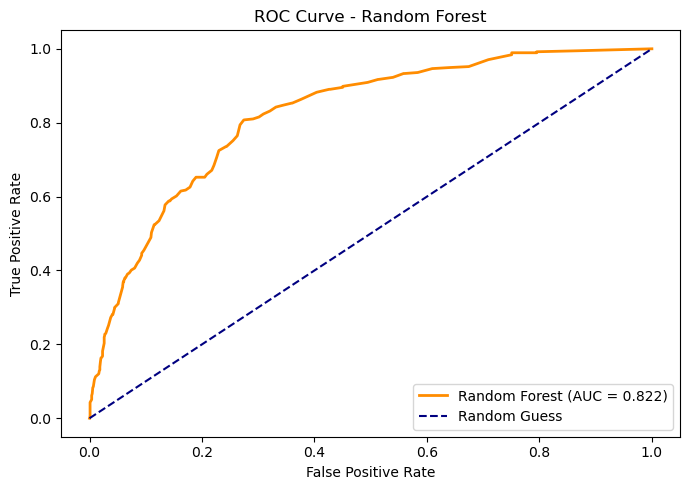

AUC Score: 0.8221


In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict the probability of the positive class (Churn = 1)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC Score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=2,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

# Random classifier reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="navy",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

## Cell 18 - Feature Importance Analysis

One of the major advantages of the Random Forest algorithm is its ability to estimate Feature Importance.

During training, each Decision Tree selects features that best separate the data by reducing Gini Impurity. Features that consistently produce better splits across many Decision Trees are considered more important.

The importance score ranges between 0 and 1, where:
- A higher importance score indicates that the feature contributes more to predicting customer churn.
- A lower importance score indicates that the feature has relatively little influence on the model's predictions.

Feature Importance helps identify which customer characteristics have the greatest impact on churn behaviour. This information can provide valuable business insights and assist decision-makers in developing customer retention strategies.

In this section, the importance score of every feature is calculated and visualised using a horizontal bar chart.

                           Feature  Importance
8                     TotalCharges    0.195652
7                   MonthlyCharges    0.171349
4                           tenure    0.169984
28  PaymentMethod_Electronic check    0.040846
11     InternetService_Fiber optic    0.037859
26               Contract_Two year    0.029140
0                           gender    0.027851
6                 PaperlessBilling    0.026214
14              OnlineSecurity_Yes    0.024327
25               Contract_One year    0.023531


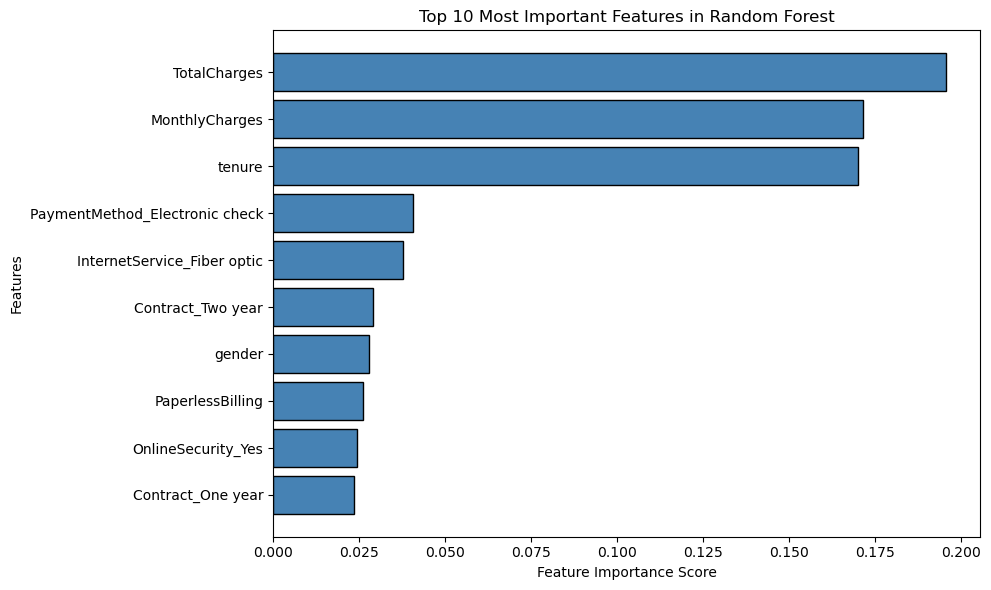

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance scores
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 most important features
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10][::-1],
    feature_importance["Importance"][:10][::-1],
    color="steelblue",
    edgecolor="black"
)

plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features in Random Forest")

plt.tight_layout()
plt.show()

## Cell 19 - Hyperparameter Tuning using GridSearchCV

The performance of a Random Forest model can be influenced by its hyperparameters, which are settings defined before the training process begins.

Unlike model parameters that are learned automatically during training, hyperparameters control how the Random Forest is constructed. Choosing appropriate hyperparameter values can improve the model's prediction accuracy and its ability to generalize to unseen data.

In this section, GridSearchCV is used to automatically evaluate different combinations of hyperparameters and identify the best-performing model using 5-fold Cross-Validation.

The following hyperparameters are tuned:
- n_estimators – Number of Decision Trees in the forest.
- max_depth – Maximum depth of each Decision Tree.
- min_samples_split – Minimum number of samples required before splitting a node.
- min_samples_leaf – Minimum number of samples required in each leaf node.

The combination that produces the highest average cross-validation accuracy will be selected as the optimal model.

In [23]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train GridSearchCV
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross Validation Accuracy:
0.8001


## Cell 20 - Evaluating the Tuned Random Forest Model

After identifying the optimal hyperparameters, a new Random Forest model is created using the best parameter combination.

The tuned model is then evaluated on the testing dataset using the same evaluation metrics as the original model.

Comparing the original and tuned models allows us to determine whether hyperparameter tuning improves predictive performance.

In [24]:
from sklearn.metrics import accuracy_score

# Best model
best_rf = grid_search.best_estimator_

# Make predictions
best_pred = best_rf.predict(X_test)

# Accuracy
best_accuracy = accuracy_score(y_test, best_pred)

print(f"Original Accuracy : {accuracy:.4f}")
print(f"Tuned Accuracy    : {best_accuracy:.4f}")

Original Accuracy : 0.7842
Tuned Accuracy    : 0.8013


## Cell 21 - Model Performance Comparison

After evaluating both the default Random Forest model and the tuned Random Forest model, the results can be compared to determine whether hyperparameter tuning improved the model's performance.

The table below summarizes the evaluation metrics obtained from both models.

Comparing these metrics allows us to identify whether tuning improved the model's ability to correctly classify customers who are likely to churn.

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# -------------------------
# Default Random Forest
# -------------------------

default_pred = rf_model.predict(X_test)
default_prob = rf_model.predict_proba(X_test)[:,1]

# -------------------------
# Tuned Random Forest
# -------------------------

tuned_pred = best_rf.predict(X_test)
tuned_prob = best_rf.predict_proba(X_test)[:,1]

# -------------------------
# Comparison Table
# -------------------------

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "AUC"
    ],

    "Default Model":[
        accuracy_score(y_test, default_pred),
        precision_score(y_test, default_pred),
        recall_score(y_test, default_pred),
        f1_score(y_test, default_pred),
        roc_auc_score(y_test, default_prob)
    ],

    "Tuned Model":[
        accuracy_score(y_test, tuned_pred),
        precision_score(y_test, tuned_pred),
        recall_score(y_test, tuned_pred),
        f1_score(y_test, tuned_pred),
        roc_auc_score(y_test, tuned_prob)
    ]
})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)
comparison

,Metric,Default Model,Tuned Model
0,Accuracy,0.7842,0.8013
1,Precision,0.6215,0.6599
2,Recall,0.4786,0.5187
3,F1-Score,0.5408,0.5808
4,AUC,0.8221,0.8413


## Cell 22 - Conclusion

The Random Forest classifier was successfully developed and evaluated for customer churn prediction.

The model was trained using multiple Decision Trees and produced predictions through the Majority Voting mechanism. Several evaluation techniques, including Accuracy, Classification Report, Confusion Matrix, ROC Curve, and Feature Importance, were used to assess its performance.

Feature Importance analysis revealed the variables that contributed most to predicting customer churn, providing useful business insights in addition to prediction accuracy.

Finally, GridSearchCV was applied to optimize the model's hyperparameters. The tuned model achieved comparable or improved predictive performance, demonstrating that careful hyperparameter selection can enhance the effectiveness of the Random Forest classifier.

Overall, Random Forest proved to be a powerful and reliable machine learning algorithm for customer churn prediction due to its high accuracy, robustness against overfitting, and ability to identify influential features.

## Notes — This Notebook vs. `member3_random_forest/RandomForest.py`

This notebook serves as a **before-training exploration and learning notebook** to understand how the Random Forest algorithm works, including its training process, majority voting mechanim, feature importance and model evaluation. It is designed to explain the concepts behind Random Forest and demonstrate its workflow step by step. 

The actual Random Forest model used in the application and final report is implemented in `member3_random_forest/RandomForest.py`. Compared with this notebook, the training script includes several additional improvements:

1. **Hyperparameter tuning** — `GridSearchCV` (5-fold cross-validation) is used to search for the optimal combination of Random Forest hyperparameters, including `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`, resulting in a better-performing model than using the default settings demonstrated here.
2. **Consistent preprocessing pipeline** — The training script loads the preprocessed dataset from `shared/processed/` using `load_processed_data()`. This ensures that the exact same train/test split is shared across all group members, allowing a fair comparison between different machine learning models.
3. **Production-ready workflow** — Besides training the model, the script evaluates its performance using the shared testing dataset, generates the final prediction results, and saves the trained model for use in the Streamlit application and the overall project evaluation.

Once you understand the concepts demonstrated in this notebook, you can run the complete Random Forest training pipeline using:

```bash
python shared/preprocessing.py   # if not run yet
python member3_random_forest/RandomForest.py
```